# Kalpitiya Deforestation Analysis
### Landsat 8 & 9 — Surface Reflectance — 2016 to 2025

This notebook runs a full deforestation analysis using USGS Landsat Collection 2 Level-2 data. The scenes here are large (~7700 x 7600 px), so the notebook is built around one strict rule: **only one scene lives in RAM at a time**. Every intermediate result is saved to disk and reloaded on demand.

**Six passes, in order:**

| Pass | What happens | Output |
|---|---|---|
| 1 | Cloud-mask + scale + save stacked TIFs | `outputs/stacked/` |
| 2 | Compute NDVI, NDWI, NDBI, NBR, EVI | `outputs/ndvi/` etc. |
| 3 | Train Random Forest classifier | `outputs/models/` |
| 4 | Classify all scenes | `outputs/classmaps/` |
| 5 | Change detection | `outputs/change/` |
| 6 | Trend analysis and forecast to 2030 | `outputs/stats/` |

Restart-safe: if you stop and restart the kernel, already-processed TIFs are detected and skipped automatically.

In [1]:
import subprocess, sys

def install_if_missing(pkg, imp=None):
    try:
        __import__(imp or pkg)
    except ImportError:
        print(f"Installing {pkg}...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", pkg, "-q"])

for pkg, imp in [("rasterio","rasterio"), ("scikit-learn","sklearn"),
                  ("seaborn","seaborn"), ("joblib","joblib")]:
    install_if_missing(pkg, imp)

print("All packages ready.")


All packages ready.


In [2]:
import os, re, gc, json, time, warnings
from pathlib import Path
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import matplotlib.dates as mdates
import seaborn as sns
import rasterio
from rasterio.enums import Resampling   # direct import — avoids rasterio.enums attribute error
import joblib

from sklearn.ensemble import RandomForestClassifier, GradientBoostingRegressor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (accuracy_score, classification_report,
                              confusion_matrix, r2_score, mean_squared_error)
from scipy import stats as scipy_stats

warnings.filterwarnings("ignore")

plt.rcParams.update({
    "font.family": "DejaVu Sans",
    "font.size": 11,
    "axes.titlesize": 13,
    "figure.dpi": 110,
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.spines.top": False,
    "axes.spines.right": False,
})

print(f"numpy    {np.__version__}")
print(f"rasterio {rasterio.__version__}")
print("Imports done.")


numpy    2.3.5
rasterio 1.4.4
Imports done.


---
## 1. Install and Import

In [ ]:
# ── Only change these two lines ──────────────────────────────────────────────
RAW_DIR    = "data/raw"
OUT_DIR    = "out"
DOWNSAMPLE = 2       # 1=full res (~1.6GB/scene), 2=half res (~415MB), 4=quarter

# Landsat Collection 2 Level-2 scaling:  SR = DN * 0.0000275 + (-0.2)
SCALE  = 0.0000275
OFFSET = -0.2

# QA_PIXEL bit flags (from the Landsat C2 product guide)
QA_FILL   = 0x0001
QA_DILCLD = 0x0002
QA_CIRRUS = 0x0004
QA_CLOUD  = 0x0008
QA_SHADOW = 0x0010

# Land cover classes
CLASS_NAMES  = {0: "Water", 1: "Vegetation", 2: "Bare Soil", 3: "Built-Up"}
CLASS_COLORS = {-1: "#cccccc", 0: "#2171b5", 1: "#238b45", 2: "#d4a843", 3: "#cb181d"}

VEG_THRESHOLD = 0.25

# Make sure DOWNSAMPLE is always a plain int — prevents tuple arithmetic errors later
DOWNSAMPLE = int(DOWNSAMPLE)
PX_HA = 0.09 * (DOWNSAMPLE ** 2)   # hectares per pixel at chosen resolution

for sub in ["stacked","ndvi","ndwi","ndbi","nbr","evi",
            "classmaps","change","graphs","stats","models"]:
    os.makedirs(os.path.join(OUT_DIR, sub), exist_ok=True)

print(f"RAW_DIR    : {os.path.abspath(RAW_DIR)}")
print(f"OUT_DIR    : {os.path.abspath(OUT_DIR)}")
print(f"DOWNSAMPLE : {DOWNSAMPLE}x  →  ~{7761//DOWNSAMPLE} x {7611//DOWNSAMPLE} px per scene")
print(f"PX_HA      : {PX_HA} ha per pixel")


RAW_DIR    : d:\Projects\GitHub\terraShiftSriLanka\data\raw
OUT_DIR    : d:\Projects\GitHub\terraShiftSriLanka\outputs
DOWNSAMPLE : 2x  →  ~3880 x 3805 px per scene
PX_HA      : 0.36 ha per pixel


In [4]:
def parse_landsat_name(fname):
    base = os.path.basename(fname)
    # Pattern: LC08_L2SP_142054_20160203_20200907_02_T1_SR_B4.TIF
    m = re.match(
        r"(LC0[89])_L2SP_(\d{6})_(\d{8})_\d{8}_\d{2}_T\d_"
        r"(SR_B[1-7]|QA_PIXEL|QA_RADSAT|SR_QA_AEROSOL)",
        base, re.IGNORECASE
    )
    if not m:
        return None
    acq = m.group(3)
    return {
        "sensor":   m.group(1).upper(),
        "path_row": m.group(2),
        "date":     datetime.strptime(acq, "%Y%m%d"),
        "band":     m.group(4).upper(),
        "label":    f"{acq[:4]}_{acq[4:6]}",
    }


def discover_scenes(raw_dir):
    raw_path = Path(raw_dir)
    if not raw_path.exists():
        raise FileNotFoundError(f"Not found: {raw_dir}")
    scenes = {}
    for folder in sorted(raw_path.iterdir()):
        if not folder.is_dir():
            continue
        label = folder.name
        tifs  = sorted(list(folder.glob("*.TIF")) + list(folder.glob("*.tif")))
        if not tifs:
            print(f"  {label}: no TIF files — skipping")
            continue
        entry = {}
        for tif in tifs:
            info = parse_landsat_name(tif.name)
            if info:
                entry[info["band"]] = str(tif)
                if "_meta" not in entry:
                    entry["_meta"] = {k: v for k, v in info.items() if k != "band"}
        if entry:
            sr  = sum(1 for k in entry if k.startswith("SR_B"))
            has = "QA_PIXEL" in entry
            dt  = entry["_meta"]["date"].strftime("%Y-%m-%d")
            print(f"  {label}  {entry['_meta']['sensor']}  {dt}  {sr}/7 bands  QA:{'yes' if has else 'NO'}")
            scenes[label] = entry
    print(f"\n  Total: {len(scenes)} scenes found")
    return scenes


print(f"Scanning {os.path.abspath(RAW_DIR)} ...\n")
SCENES = discover_scenes(RAW_DIR)
LABELS = sorted(SCENES.keys())


Scanning d:\Projects\GitHub\terraShiftSriLanka\data\raw ...

  2016_02  LC08  2016-02-03  7/7 bands  QA:yes
  2016_03  LC08  2016-03-06  7/7 bands  QA:yes
  2017_02  LC08  2017-02-05  7/7 bands  QA:yes
  2017_03  LC08  2017-03-25  7/7 bands  QA:yes
  2018_02  LC08  2018-02-08  7/7 bands  QA:yes
  2018_03  LC08  2018-03-28  7/7 bands  QA:yes
  2019_02  LC08  2019-02-11  7/7 bands  QA:yes
  2019_03  LC08  2019-03-15  7/7 bands  QA:yes
  2020_02  LC08  2020-02-14  7/7 bands  QA:yes
  2020_03  LC08  2020-03-01  7/7 bands  QA:yes
  2021_02  LC08  2021-02-16  7/7 bands  QA:yes
  2021_03  LC08  2021-03-04  7/7 bands  QA:yes
  2022_02  LC09  2022-02-27  7/7 bands  QA:yes
  2022_03  LC08  2022-03-23  7/7 bands  QA:yes
  2023_02  LC09  2023-02-14  7/7 bands  QA:yes
  2023_03  LC09  2023-03-18  7/7 bands  QA:yes
  2024_02  LC09  2024-02-17  7/7 bands  QA:yes
  2024_03  LC09  2024-03-04  7/7 bands  QA:yes
  2025_02  LC09  2025-02-03  7/7 bands  QA:yes
  2025_03  LC09  2025-03-07  7/7 bands  QA:yes

---
## 2. Configuration

`DOWNSAMPLE = 2` is the recommended default. Your scenes are 7761x7611 px. Memory cost per scene at each setting:

| DOWNSAMPLE | Approx. size | Stack RAM |
|---|---|---|
| 1 | 7761 x 7611 | ~1.6 GB |
| 2 | 3880 x 3805 | ~415 MB |
| 4 | 1940 x 1903 | ~105 MB |

  Label Sensor       Date  SR Bands Has QA
2016_02   LC08 2016-02-03         7    yes
2016_03   LC08 2016-03-06         7    yes
2017_02   LC08 2017-02-05         7    yes
2017_03   LC08 2017-03-25         7    yes
2018_02   LC08 2018-02-08         7    yes
2018_03   LC08 2018-03-28         7    yes
2019_02   LC08 2019-02-11         7    yes
2019_03   LC08 2019-03-15         7    yes
2020_02   LC08 2020-02-14         7    yes
2020_03   LC08 2020-03-01         7    yes
2021_02   LC08 2021-02-16         7    yes
2021_03   LC08 2021-03-04         7    yes
2022_02   LC09 2022-02-27         7    yes
2022_03   LC08 2022-03-23         7    yes
2023_02   LC09 2023-02-14         7    yes
2023_03   LC09 2023-03-18         7    yes
2024_02   LC09 2024-02-17         7    yes
2024_03   LC09 2024-03-04         7    yes
2025_02   LC09 2025-02-03         7    yes
2025_03   LC09 2025-03-07         7    yes


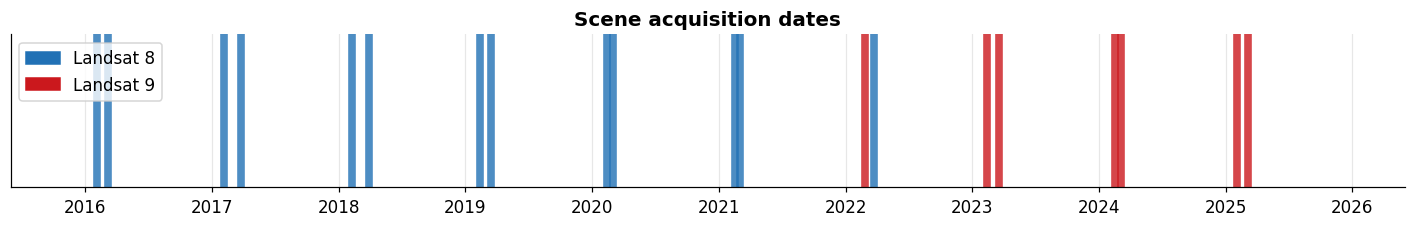

In [5]:
rows = []
for lbl in LABELS:
    meta = SCENES[lbl]["_meta"]
    rows.append({
        "Label":    lbl,
        "Sensor":   meta["sensor"],
        "Date":     meta["date"].strftime("%Y-%m-%d"),
        "SR Bands": sum(1 for k in SCENES[lbl] if k.startswith("SR_B")),
        "Has QA":   "yes" if "QA_PIXEL" in SCENES[lbl] else "NO",
    })
df_inv = pd.DataFrame(rows)
print(df_inv.to_string(index=False))

# Timeline plot — use matplotlib date numbers to avoid Timestamp/float xlim error
fig, ax = plt.subplots(figsize=(13, 2.2))
sensor_colors = {"LC08": "#2171b5", "LC09": "#cb181d"}
for _, r in df_inv.iterrows():
    c = sensor_colors.get(r["Sensor"], "gray")
    try:
        dt_num = mdates.date2num(datetime.strptime(r["Date"], "%Y-%m-%d"))
        ax.axvline(dt_num, color=c, lw=5, alpha=0.8)
    except Exception:
        pass
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.legend(handles=[mpatches.Patch(color="#2171b5", label="Landsat 8"),
                    mpatches.Patch(color="#cb181d", label="Landsat 9")], loc="upper left")
ax.set_title("Scene acquisition dates", fontweight="bold")
ax.yaxis.set_visible(False)
try:
    ax.set_xlim(mdates.date2num(datetime(2015, 6, 1)),
                mdates.date2num(datetime(2026, 6, 1)))
except Exception:
    pass
ax.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/graphs/01_timeline.png", dpi=130, bbox_inches="tight")
plt.show()


In [6]:
def load_band(path, downsample=1):
    """Load one SR band, scale to surface reflectance, return float32 array."""
    with rasterio.open(path) as src:
        if downsample == 1:
            arr     = src.read(1).astype(np.float32)
            profile = src.profile.copy()
        else:
            out_h = src.height // downsample
            out_w = src.width  // downsample
            arr   = src.read(
                1,
                out_shape=(out_h, out_w),
                resampling=Resampling.bilinear
            ).astype(np.float32)
            new_t   = src.transform * src.transform.scale(
                src.width  / out_w,
                src.height / out_h
            )
            profile = src.profile.copy()
            profile.update(height=out_h, width=out_w, transform=new_t)
        nodata = src.nodata
    if nodata is not None:
        arr[arr == nodata] = np.nan
    arr = np.clip(arr * SCALE + OFFSET, 0.0, 1.0)
    return arr, profile


def load_qa(path, downsample=1):
    """Load QA_PIXEL, return boolean mask — True = bad pixel."""
    with rasterio.open(path) as src:
        if downsample == 1:
            qa = src.read(1).astype(np.uint16)
        else:
            out_h = src.height // downsample
            out_w = src.width  // downsample
            qa    = src.read(
                1,
                out_shape=(out_h, out_w),
                resampling=Resampling.nearest
            ).astype(np.uint16)
    bad = (((qa & QA_FILL)   > 0) |
           ((qa & QA_CLOUD)  > 0) |
           ((qa & QA_DILCLD) > 0) |
           ((qa & QA_SHADOW) > 0) |
           ((qa & QA_CIRRUS) > 0))
    return bad


def save_raster(arr, profile, path):
    """Save a numpy array as a compressed GeoTIFF."""
    os.makedirs(os.path.dirname(path) or ".", exist_ok=True)
    if arr.ndim == 2:
        arr = arr[np.newaxis]
    p = profile.copy()
    p.update(count=arr.shape[0], dtype="float32",
             driver="GTiff", compress="lzw", nodata=float("nan"),
             BIGTIFF="YES")
    with rasterio.open(path, "w", **p) as dst:
        dst.write(arr.astype(np.float32))


def pct_stretch(arr, lo=2, hi=98):
    """Percentile contrast stretch for display — maps lo..hi percentiles to 0..1."""
    p_lo = np.nanpercentile(arr, lo)
    p_hi = np.nanpercentile(arr, hi)
    return np.clip((arr - p_lo) / (p_hi - p_lo + 1e-9), 0.0, 1.0)


def read_index_tif(label, name):
    """Load a saved single-band index TIF from disk."""
    path = f"{OUT_DIR}/{name}/{label}_{name}.tif"
    with rasterio.open(path) as src:
        return src.read(1).astype(np.float32)


print("I/O helpers defined.")


I/O helpers defined.


---
## 3. Scene Discovery

Builds a catalogue of file paths from the folder names. Nothing is loaded into memory here.

In [7]:
# Pass 1 — load, cloud-mask, scale, save stacked TIF for every scene.
# Only one scene lives in RAM at a time. After save() we del and gc.collect().
# If the stacked TIF already exists the scene is skipped automatically.

print(f"Preprocessing  (DOWNSAMPLE={DOWNSAMPLE}) ...\n")
cloud_log = {}

for label in LABELS:
    out_path  = f"{OUT_DIR}/stacked/{label}_stack.tif"
    side_path = f"{OUT_DIR}/stacked/{label}_cloud.txt"

    if os.path.exists(out_path):
        cloud_log[label] = float(open(side_path).read()) if os.path.exists(side_path) else 0.0
        print(f"  {label}  already done  (cloud={cloud_log[label]:.1f}%)")
        continue

    t0    = time.time()
    scene = SCENES[label]
    bands   = []
    profile = None

    for i in range(1, 8):
        bk = f"SR_B{i}"
        if bk not in scene:
            print(f"  {label}  WARNING: {bk} missing — scene skipped")
            bands = []
            break
        arr, prof = load_band(scene[bk], downsample=DOWNSAMPLE)
        bands.append(arr)
        del arr
        if profile is None:
            profile = prof

    if not bands:
        continue

    stack = np.stack(bands, axis=0).astype(np.float32)   # (7, H, W)
    del bands
    gc.collect()

    cloud_pct = 0.0
    if "QA_PIXEL" in scene:
        bad_px    = load_qa(scene["QA_PIXEL"], downsample=DOWNSAMPLE)
        cloud_pct = 100.0 * float(bad_px.sum()) / float(bad_px.size)
        stack[:, bad_px] = np.nan
        del bad_px

    save_raster(stack, profile, out_path)
    cloud_log[label] = cloud_pct
    with open(side_path, "w") as f:
        f.write(str(cloud_pct))

    h, w   = stack.shape[1], stack.shape[2]
    mem_mb = stack.nbytes / 1e6
    del stack
    gc.collect()

    print(f"  {label}  {h}x{w}  cloud={cloud_pct:.1f}%  {mem_mb:.0f}MB  ({time.time()-t0:.1f}s)")

print(f"\nDone. Stacked TIFs in {OUT_DIR}/stacked/")


Preprocessing  (DOWNSAMPLE=2) ...

  2016_02  already done  (cloud=100.0%)


IndexError: tuple index out of range

In [ ]:
# Cloud cover bar chart — reading from cloud_log dict, not rasters

fig, ax = plt.subplots(figsize=(13, 3.5))
labels_plot = list(cloud_log.keys())
values_plot = list(cloud_log.values())
bar_colors  = ["#238b45" if v < 30 else "#d4a843" if v < 60 else "#cb181d"
               for v in values_plot]

ax.bar(labels_plot, values_plot, color=bar_colors, edgecolor="white", width=0.65)
ax.axhline(30, color="#666", ls="--", lw=1.2, label="30% threshold")
ax.set_ylabel("Cloud cover (%)")
ax.set_title("Cloud cover per scene  (green<30%  orange 30-60%  red>60%)",
             fontweight="bold")
ax.legend()
plt.xticks(rotation=35, ha="right")
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/graphs/02_cloud_cover.png", dpi=130, bbox_inches="tight")
plt.show()


---
## 4. Preprocessing

Loads each scene one at a time, applies the QA_PIXEL cloud mask, scales bands to surface reflectance, saves a stacked GeoTIFF, then immediately frees the array. Peak RAM = one scene at a time.

In [ ]:
# RGB preview grid — one scene loaded, plotted, then freed before next scene.

ncols = 3
nrows = (len(LABELS) + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 4.5, nrows * 4.2))
axes = np.array(axes).ravel()

for i, label in enumerate(LABELS):
    stk_path = f"{OUT_DIR}/stacked/{label}_stack.tif"
    if not os.path.exists(stk_path):
        axes[i].set_title(f"{label} — missing")
        axes[i].axis("off")
        continue

    with rasterio.open(stk_path) as src:
        r = src.read(4).astype(np.float32)   # B4 red
        g = src.read(3).astype(np.float32)   # B3 green
        b = src.read(2).astype(np.float32)   # B2 blue

    rgb = np.stack([pct_stretch(r), pct_stretch(g), pct_stretch(b)], axis=-1)
    del r, g, b
    gc.collect()

    axes[i].imshow(rgb)
    axes[i].set_title(f"True colour — {label}", fontsize=9, fontweight="bold")
    axes[i].axis("off")
    del rgb
    gc.collect()

for j in range(len(LABELS), len(axes)):
    axes[j].set_visible(False)

plt.suptitle("True Colour Composites (cloud-masked)", fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/graphs/02_rgb_grid.png", dpi=100, bbox_inches="tight")
plt.show()


In [ ]:
def safe_ratio(a, b):
    """Normalised difference (a-b)/(a+b), NaN where denominator is near zero."""
    a = a.astype(np.float32)
    b = b.astype(np.float32)
    with np.errstate(invalid="ignore", divide="ignore"):
        denom  = a + b
        result = np.where(np.abs(denom) > 1e-9, (a - b) / denom, np.nan)
    return result.astype(np.float32)


def compute_indices(stack):
    """
    Compute spectral indices from a 7-band Landsat stack.

    Band order (0-based index):
      0=B1  1=B2(Blue)  2=B3(Green)  3=B4(Red)
      4=B5(NIR)  5=B6(SWIR1)  6=B7(SWIR2)
    """
    blue  = stack[1];  green = stack[2];  red   = stack[3]
    nir   = stack[4];  swir1 = stack[5];  swir2 = stack[6]

    ndvi = np.clip(safe_ratio(nir,   red),   -1.0, 1.0)
    ndwi = np.clip(safe_ratio(green, nir),   -1.0, 1.0)
    ndbi = np.clip(safe_ratio(swir1, nir),   -1.0, 1.0)
    nbr  = np.clip(safe_ratio(nir,   swir2), -1.0, 1.0)

    # EVI has a different denominator
    with np.errstate(invalid="ignore", divide="ignore"):
        d_evi = nir.astype(np.float32) + 6.0 * red.astype(np.float32) \
                - 7.5 * blue.astype(np.float32) + 1.0
        evi = np.where(
            np.abs(d_evi) > 1e-9,
            2.5 * (nir.astype(np.float32) - red.astype(np.float32)) / d_evi,
            np.nan
        ).astype(np.float32)
    evi = np.clip(evi, -1.0, 1.0)

    return {"ndvi": ndvi, "ndwi": ndwi, "ndbi": ndbi, "nbr": nbr, "evi": evi}


print("Index functions defined.")


In [ ]:
# Pass 2 — compute all spectral indices, save each to its own TIF, free RAM.
# We also collect NDVI statistics here into a tiny DataFrame that stays in RAM.

print("Computing spectral indices ...\n")
stats_rows = []

for label in LABELS:
    stk_path = f"{OUT_DIR}/stacked/{label}_stack.tif"
    if not os.path.exists(stk_path):
        print(f"  {label}: stacked TIF missing — run preprocessing cell first")
        continue

    t0 = time.time()

    with rasterio.open(stk_path) as src:
        stack   = src.read().astype(np.float32)   # (7, H, W)
        profile = src.profile.copy()

    idx = compute_indices(stack)
    del stack
    gc.collect()

    # Save each index TIF — only if not already saved
    one_band = profile.copy()
    one_band.update(count=1, dtype="float32", compress="lzw",
                    nodata=float("nan"), BIGTIFF="YES")
    for iname, arr in idx.items():
        out_path = f"{OUT_DIR}/{iname}/{label}_{iname}.tif"
        if not os.path.exists(out_path):
            save_raster(arr, one_band, out_path)

    # Collect stats while arrays are in memory (cheap — just numbers)
    valid = idx["ndvi"][~np.isnan(idx["ndvi"])].ravel()
    if len(valid) > 1000:
        yr, mo = int(label[:4]), int(label[5:])
        stats_rows.append({
            "label":        label,
            "year":         yr,
            "month":        mo,
            "date_frac":    yr + (mo - 1) / 12.0,
            "mean_ndvi":    float(valid.mean()),
            "std_ndvi":     float(valid.std()),
            "median_ndvi":  float(np.median(valid)),
            "p10":          float(np.percentile(valid, 10)),
            "p90":          float(np.percentile(valid, 90)),
            "mean_ndwi":    float(np.nanmean(idx["ndwi"])),
            "mean_ndbi":    float(np.nanmean(idx["ndbi"])),
            "pct_dense":    float(100.0 * (valid > 0.50).mean()),
            "pct_moderate": float(100.0 * ((valid > 0.25) & (valid <= 0.50)).mean()),
            "pct_sparse":   float(100.0 * ((valid > 0.00) & (valid <= 0.25)).mean()),
            "pct_nonveg":   float(100.0 * (valid <= 0.00).mean()),
            "n_valid_px":   int(len(valid)),
        })

    mn = float(np.nanmean(idx["ndvi"]))
    mw = float(np.nanmean(idx["ndwi"]))
    mb = float(np.nanmean(idx["ndbi"]))
    print(f"  {label}  NDVI={mn:+.4f}  NDWI={mw:+.4f}  NDBI={mb:+.4f}  ({time.time()-t0:.1f}s)")

    del idx, valid
    gc.collect()

df_ts = pd.DataFrame(stats_rows).sort_values("date_frac").reset_index(drop=True)
df_ts.to_csv(f"{OUT_DIR}/stats/index_statistics.csv", index=False)
print(f"\nStats saved. {len(df_ts)} scenes in time-series DataFrame.")


In [ ]:
# NDVI grid — each TIF is loaded, plotted, and freed before loading the next.

ncols = 4
nrows = (len(LABELS) + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 4.3, nrows * 4.0))
axes = np.array(axes).ravel()

for i, label in enumerate(LABELS):
    ndvi_path = f"{OUT_DIR}/ndvi/{label}_ndvi.tif"
    if not os.path.exists(ndvi_path):
        axes[i].set_title(f"{label} — missing")
        axes[i].axis("off")
        continue

    with rasterio.open(ndvi_path) as src:
        arr = src.read(1).astype(np.float32)

    im = axes[i].imshow(arr, cmap="RdYlGn", vmin=-0.15, vmax=0.75)
    axes[i].set_title(f"NDVI  {label}", fontsize=9, fontweight="bold")
    axes[i].axis("off")
    plt.colorbar(im, ax=axes[i], fraction=0.046, pad=0.03, shrink=0.85)
    del arr
    gc.collect()

for j in range(len(LABELS), len(axes)):
    axes[j].set_visible(False)

plt.suptitle("NDVI — all scenes", fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/graphs/03_ndvi_grid.png", dpi=100, bbox_inches="tight")
plt.show()


---
## 5. Spectral Indices

NDVI, NDWI, NDBI, NBR, EVI — computed per scene, saved as individual TIFs, freed. A small statistics DataFrame (just numbers) is kept in RAM for the forecasting step.

In [ ]:
# NDVI histogram comparison — subsampled to 300k pixels per scene
# so this stays fast and light regardless of raster size.

fig, ax = plt.subplots(figsize=(13, 5))

# Use colormaps properly — works across all matplotlib versions
cmap_fn = matplotlib.colormaps.get_cmap("viridis")
palette  = [cmap_fn(x) for x in np.linspace(0.1, 0.9, len(LABELS))]

for i, label in enumerate(LABELS):
    ndvi_path = f"{OUT_DIR}/ndvi/{label}_ndvi.tif"
    if not os.path.exists(ndvi_path):
        continue

    with rasterio.open(ndvi_path) as src:
        arr = src.read(1).astype(np.float32)

    valid = arr[~np.isnan(arr)].ravel()
    del arr
    gc.collect()

    if len(valid) > 300_000:
        rng   = np.random.default_rng(42)
        valid = rng.choice(valid, 300_000, replace=False)

    ax.hist(valid, bins=150, density=True, histtype="stepfilled",
            alpha=0.45, color=palette[i], edgecolor="none",
            label=label.replace("_", "/"))
    del valid

ax.axvline(VEG_THRESHOLD, color="black", ls="--", lw=1.5,
           label=f"Veg threshold ({VEG_THRESHOLD})")
ax.set_xlabel("NDVI")
ax.set_ylabel("Density")
ax.set_title("NDVI distributions across all scenes\n"
             "A shift left over time = vegetation decline", fontweight="bold")
ax.legend(ncol=4, fontsize=8)
ax.set_xlim(-0.25, 0.85)
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/graphs/03_ndvi_distributions.png", dpi=130, bbox_inches="tight")
plt.show()


In [ ]:
def pseudo_labels(ndvi_f, ndwi_f, ndbi_f):
    """
    Rule-based pseudo-label generator.
    Only labels pixels we are confident about — ambiguous ones stay -1.

    Classes:
      0 = Water        1 = Vegetation
      2 = Bare Soil    3 = Built-Up / Scrub
    """
    lab = np.full(len(ndvi_f), -1, dtype=np.int8)
    lab[(ndvi_f > 0.05)  & (ndvi_f < 0.22) & (np.abs(ndbi_f) < 0.12)] = 2  # bare
    lab[(ndbi_f > 0.08)  & (ndvi_f < 0.12)]                             = 3  # built-up
    lab[(ndwi_f > 0.15)  & (ndvi_f < 0.02)]                             = 0  # water
    lab[(ndvi_f > 0.32)  & (ndwi_f < -0.05)]                            = 1  # vegetation
    return lab


def build_feature_matrix(stack, ndvi, ndwi, ndbi, nbr, evi):
    """
    Stack bands + indices into (N_valid_pixels, 11) feature matrix.
    Returns (X, valid_mask) where valid_mask is bool (H, W).
    """
    layers = [
        stack[1], stack[2], stack[3],     # B2 B3 B4
        stack[4], stack[5], stack[6],     # B5 B6 B7
        ndvi, ndwi, ndbi, nbr, evi,
    ]
    cube       = np.stack(layers, axis=0)            # (11, H, W)
    valid_mask = ~np.any(np.isnan(cube), axis=0)     # (H, W)
    X = cube.reshape(11, -1).T[valid_mask.ravel()]
    del cube
    return X.astype(np.float32), valid_mask


FEATURE_NAMES = ["B2","B3","B4","B5","B6","B7","NDVI","NDWI","NDBI","NBR","EVI"]
print("Classification helpers defined.")


In [ ]:
# Pass 3 — Train Random Forest on the earliest scene.
# All large arrays are freed after training. RF + SCALER stay in RAM
# (they are small) and are also saved to disk.

ref_label = LABELS[0]
print(f"Training on: {ref_label}\n")

# Load stack and all five index TIFs for the reference scene
with rasterio.open(f"{OUT_DIR}/stacked/{ref_label}_stack.tif") as src:
    ref_stack = src.read().astype(np.float32)

r_ndvi = read_index_tif(ref_label, "ndvi")
r_ndwi = read_index_tif(ref_label, "ndwi")
r_ndbi = read_index_tif(ref_label, "ndbi")
r_nbr  = read_index_tif(ref_label, "nbr")
r_evi  = read_index_tif(ref_label, "evi")

X_all, vmask = build_feature_matrix(ref_stack, r_ndvi, r_ndwi, r_ndbi, r_nbr, r_evi)
del ref_stack, r_nbr, r_evi
gc.collect()

# Generate pseudo-labels for the valid-pixel positions
labels_all = pseudo_labels(r_ndvi[vmask], r_ndwi[vmask], r_ndbi[vmask])
del r_ndvi, r_ndwi, r_ndbi, vmask
gc.collect()

# Keep only the labelled (confident) pixels for training
keep      = labels_all >= 0
X_lab     = X_all[keep]
y_lab     = labels_all[keep]
del X_all, labels_all
gc.collect()

print(f"Labelled training pixels: {len(y_lab):,}")
for cid, cname in CLASS_NAMES.items():
    n = int((y_lab == cid).sum())
    print(f"  {cname:<22} {n:>9,}  ({100*n/len(y_lab):.1f}%)")

# Scale
SCALER  = StandardScaler()
X_sc    = SCALER.fit_transform(X_lab)
del X_lab
gc.collect()

X_tr, X_te, y_tr, y_te = train_test_split(
    X_sc, y_lab, test_size=0.25, stratify=y_lab, random_state=42
)
del X_sc, y_lab
gc.collect()

print(f"\nTrain: {len(X_tr):,}   Test: {len(X_te):,}")
print("Training Random Forest (200 trees) ...")

t0 = time.time()
RF = RandomForestClassifier(
    n_estimators=200, max_depth=15, min_samples_leaf=5,
    max_features="sqrt", class_weight="balanced",
    oob_score=True, n_jobs=-1, random_state=42,
)
RF.fit(X_tr, y_tr)

y_pred_te = RF.predict(X_te)
print(f"\nTraining time : {time.time()-t0:.1f}s")
print(f"OOB accuracy  : {RF.oob_score_:.4f}")
print(f"Test accuracy : {accuracy_score(y_te, y_pred_te):.4f}")

joblib.dump(RF,     f"{OUT_DIR}/models/rf_model.pkl")
joblib.dump(SCALER, f"{OUT_DIR}/models/scaler.pkl")
del X_tr
gc.collect()
print("\nModel saved.")


---
## 6. Land Cover Classification

**Pass 3 — Train:** Reference scene loaded once, RF trained, model saved, everything freed.

**Pass 4 — Classify:** Each scene loaded, predicted, map saved, freed.

Features (11): B2 B3 B4 B5 B6 B7 + NDVI NDWI NDBI NBR EVI

In [ ]:
# Evaluation — RF and y_pred_te are still in memory from the training cell.
# If you restarted the kernel, reload from disk first:
#   RF = joblib.load(f"{OUT_DIR}/models/rf_model.pkl")
#   SCALER = joblib.load(f"{OUT_DIR}/models/scaler.pkl")

print(classification_report(y_te, y_pred_te,
      target_names=[CLASS_NAMES[i] for i in range(4)]))

cm = confusion_matrix(y_te, y_pred_te)
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.heatmap(cm, annot=True, fmt=",d", cmap="Blues",
            xticklabels=[CLASS_NAMES[i] for i in range(4)],
            yticklabels=[CLASS_NAMES[i] for i in range(4)], ax=axes[0])
axes[0].set_xlabel("Predicted", fontweight="bold")
axes[0].set_ylabel("Actual",    fontweight="bold")
axes[0].set_title("Confusion Matrix", fontweight="bold")

fi    = RF.feature_importances_
order = np.argsort(fi)
axes[1].barh(np.array(FEATURE_NAMES)[order], fi[order].astype(float),
             color="#2171b5", alpha=0.8)
axes[1].set_xlabel("Mean Decrease in Impurity")
axes[1].set_title("Feature Importances", fontweight="bold")
axes[1].grid(axis="x", alpha=0.3)

plt.tight_layout()
plt.savefig(f"{OUT_DIR}/graphs/04_rf_evaluation.png", dpi=130, bbox_inches="tight")
plt.show()

del y_te, y_pred_te, cm
gc.collect()


In [ ]:
# Pass 4 — classify every scene using the trained model.
# If you restarted the kernel, the model is loaded from disk automatically.

if "RF" not in dir():
    RF     = joblib.load(f"{OUT_DIR}/models/rf_model.pkl")
    SCALER = joblib.load(f"{OUT_DIR}/models/scaler.pkl")
    print("Model loaded from disk.")

print("Classifying all scenes ...\n")
area_records = []

for label in LABELS:
    stk_path  = f"{OUT_DIR}/stacked/{label}_stack.tif"
    cmap_path = f"{OUT_DIR}/classmaps/{label}_classmap.tif"

    if not os.path.exists(stk_path):
        print(f"  {label}: stacked TIF missing")
        continue

    t0 = time.time()

    with rasterio.open(stk_path) as src:
        stk     = src.read().astype(np.float32)
        profile = src.profile.copy()

    H, W = stk.shape[1], stk.shape[2]

    ndvi = read_index_tif(label, "ndvi")
    ndwi = read_index_tif(label, "ndwi")
    ndbi = read_index_tif(label, "ndbi")
    nbr  = read_index_tif(label, "nbr")
    evi  = read_index_tif(label, "evi")

    X_all, vmask = build_feature_matrix(stk, ndvi, ndwi, ndbi, nbr, evi)
    del stk, ndvi, ndwi, ndbi, nbr, evi
    gc.collect()

    X_sc = SCALER.transform(X_all)
    del X_all
    gc.collect()

    # Predict in chunks of 500k to cap peak memory
    CHUNK = 500_000
    preds = np.empty(X_sc.shape[0], dtype=np.int8)
    for start in range(0, len(X_sc), CHUNK):
        preds[start:start+CHUNK] = RF.predict(X_sc[start:start+CHUNK]).astype(np.int8)
    del X_sc
    gc.collect()

    cmap_flat = np.full(H * W, -1, dtype=np.int8)
    cmap_flat[vmask.ravel()] = preds
    cmap = cmap_flat.reshape(H, W)
    del cmap_flat, preds, vmask
    gc.collect()

    # Save classification map
    p1 = profile.copy()
    p1.update(count=1, dtype="float32", compress="lzw", nodata=-1.0, BIGTIFF="YES")
    save_raster(cmap.astype(np.float32), p1, cmap_path)

    # Area statistics
    total_valid = int((cmap >= 0).sum())
    row = {"label": label}
    for cid, cname in CLASS_NAMES.items():
        key = cname.replace(" ", "_").replace("/", "").replace("-", "")
        n   = int((cmap == cid).sum())
        row[f"{key}_pct"] = round(100 * n / total_valid if total_valid > 0 else 0, 2)
        row[f"{key}_ha"]  = round(n * PX_HA, 1)
    area_records.append(row)

    veg = row.get("Vegetation_pct", 0)
    wat = row.get("Water_pct", 0)
    print(f"  {label}  veg={veg:.1f}%  water={wat:.1f}%  ({time.time()-t0:.1f}s)")

    del cmap
    gc.collect()

df_areas = pd.DataFrame(area_records)
df_areas.to_csv(f"{OUT_DIR}/stats/class_areas.csv", index=False)
print(f"\nClassification done. Area stats saved.")


In [ ]:
# Classification map grid + area stacked bar chart.
# Each classmap TIF is loaded, drawn, and freed before loading the next.

def draw_classmap(arr, title, ax):
    clist    = [CLASS_COLORS[c] for c in sorted(CLASS_COLORS)]
    bounds   = [c - 0.5 for c in sorted(CLASS_COLORS)] + [max(CLASS_COLORS) + 0.5]
    cmap_obj = mcolors.ListedColormap(clist)
    norm_obj = mcolors.BoundaryNorm(bounds, cmap_obj.N)
    ax.imshow(arr, cmap=cmap_obj, norm=norm_obj, interpolation="nearest")
    ax.set_title(title, fontweight="bold", fontsize=9)
    ax.axis("off")
    patches = [mpatches.Patch(color=CLASS_COLORS[c], label=CLASS_NAMES[c])
               for c in range(4)]
    ax.legend(handles=patches, loc="lower right", fontsize=6, framealpha=0.85)


ncols = 4
nrows = (len(LABELS) + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 4.3, nrows * 4.0))
axes = np.array(axes).ravel()

for i, label in enumerate(LABELS):
    path = f"{OUT_DIR}/classmaps/{label}_classmap.tif"
    if not os.path.exists(path):
        axes[i].set_title(f"{label} — missing")
        axes[i].axis("off")
        continue
    with rasterio.open(path) as src:
        arr = src.read(1).astype(np.float32)
    draw_classmap(arr, label, axes[i])
    del arr
    gc.collect()

for j in range(len(LABELS), len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Land Cover Classification — all scenes", fontsize=13,
             fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/graphs/04_classmaps.png", dpi=100, bbox_inches="tight")
plt.show()

# Area stacked bar
fig, ax = plt.subplots(figsize=(14, 5))
bottom_arr = np.zeros(len(df_areas))

col_cfg = [
    ("Water",       "#2171b5"),
    ("Vegetation",  "#238b45"),
    ("BareSoil",    "#d4a843"),
    ("BuiltUp",     "#cb181d"),
]

for key_prefix, col_c in col_cfg:
    col_name = next((c for c in df_areas.columns
                     if c.startswith(key_prefix) and c.endswith("_pct")), None)
    if col_name is None:
        continue
    vals = df_areas[col_name].fillna(0).to_numpy().astype(float)
    ax.bar(df_areas["label"].tolist(), vals, bottom=bottom_arr,
           label=key_prefix.replace("BareSoil","Bare Soil").replace("BuiltUp","Built-Up"),
           color=col_c, edgecolor="white", width=0.65)
    bottom_arr += vals

ax.set_ylabel("% of scene")
ax.set_xlabel("Scene date")
ax.set_title("Land cover composition over time", fontweight="bold")
ax.legend(loc="upper right", fontsize=10)
ax.set_ylim(0, 110)
plt.xticks(rotation=35, ha="right")
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/graphs/04_area_over_time.png", dpi=130, bbox_inches="tight")
plt.show()


In [ ]:
def veg_change_stats(ndvi_t1, ndvi_t2, thresh=VEG_THRESHOLD):
    """
    Quantify vegetation gain and loss between two NDVI images.
    Returns pixel counts and areas in hectares.
    """
    h = min(ndvi_t1.shape[0], ndvi_t2.shape[0])
    w = min(ndvi_t1.shape[1], ndvi_t2.shape[1])
    t1, t2 = ndvi_t1[:h, :w], ndvi_t2[:h, :w]
    valid  = (~np.isnan(t1)) & (~np.isnan(t2))
    v1 = (t1 > thresh) & valid
    v2 = (t2 > thresh) & valid
    n1, n2  = int(v1.sum()), int(v2.sum())
    lost    = int((v1 & ~v2).sum())
    gained  = int((~v1 & v2).sum())
    return {
        "n_veg_t1":  n1,  "n_veg_t2":  n2,
        "lost_px":   lost, "gained_px": gained,
        "lost_ha":   round(lost        * PX_HA, 1),
        "gained_ha": round(gained      * PX_HA, 1),
        "net_ha":    round((n2 - n1)   * PX_HA, 1),
        "pct_loss":  round(100 * lost   / n1 if n1 > 0 else 0.0, 2),
        "pct_gain":  round(100 * gained / n1 if n1 > 0 else 0.0, 2),
        "pct_net":   round(100 * (n2 - n1) / n1 if n1 > 0 else 0.0, 2),
    }


print("Change detection helpers defined.")


---
## 7. Change Detection

Loads NDVI TIFs two at a time. All raster arrays freed after each comparison.

In [ ]:
# Main change detection: earliest scene vs latest scene.
# Loads two NDVI TIFs, computes the difference, frees both.

sorted_labels = df_ts["label"].tolist()
T1, T2 = sorted_labels[0], sorted_labels[-1]

with rasterio.open(f"{OUT_DIR}/ndvi/{T1}_ndvi.tif") as src:
    ndvi_t1  = src.read(1).astype(np.float32)
    ref_prof = src.profile.copy()

with rasterio.open(f"{OUT_DIR}/ndvi/{T2}_ndvi.tif") as src:
    ndvi_t2 = src.read(1).astype(np.float32)

h = min(ndvi_t1.shape[0], ndvi_t2.shape[0])
w = min(ndvi_t1.shape[1], ndvi_t2.shape[1])
diff = (ndvi_t2[:h, :w] - ndvi_t1[:h, :w]).astype(np.float32)

chg = np.zeros_like(diff, dtype=np.int8)
chg[diff < -0.08]  = -1   # loss
chg[diff >  0.08]  =  1   # gain
chg[np.isnan(diff)] = -99  # no data

vstats = veg_change_stats(ndvi_t1, ndvi_t2)

print(f"{'='*52}")
print(f"  Vegetation change  {T1}  to  {T2}")
print(f"{'='*52}")
print(f"  Veg area at {T1}  : {vstats['n_veg_t1']:>10,} px  ({vstats['n_veg_t1'] * PX_HA:>10,.0f} ha)")
print(f"  Veg area at {T2}  : {vstats['n_veg_t2']:>10,} px  ({vstats['n_veg_t2'] * PX_HA:>10,.0f} ha)")
print(f"  Area lost          : {vstats['lost_px']:>10,} px  ({vstats['lost_ha']:>8,.1f} ha)  {vstats['pct_loss']:+.2f}%")
print(f"  Area gained        : {vstats['gained_px']:>10,} px  ({vstats['gained_ha']:>8,.1f} ha)  {vstats['pct_gain']:+.2f}%")
print(f"  Net change         :                  ({vstats['net_ha']:>+8,.1f} ha)  {vstats['pct_net']:+.2f}%")
print(f"  Mean delta NDVI    : {float(np.nanmean(diff)):>+.4f}")
print(f"{'='*52}")

with open(f"{OUT_DIR}/stats/vegetation_change.json", "w") as f:
    json.dump({**vstats, "T1": T1, "T2": T2,
               "mean_delta": round(float(np.nanmean(diff)), 4)}, f, indent=2)

save_raster(diff,           ref_prof, f"{OUT_DIR}/change/{T1}_to_{T2}_delta_ndvi.tif")
save_raster(chg.astype(np.float32), ref_prof, f"{OUT_DIR}/change/{T1}_to_{T2}_change_class.tif")


In [ ]:
# Change detection maps — ndvi_t1, ndvi_t2, diff, chg all still in memory.

fig, axes = plt.subplots(1, 3, figsize=(17, 5.5))

im0 = axes[0].imshow(ndvi_t1, cmap="RdYlGn", vmin=-0.15, vmax=0.75)
axes[0].set_title(f"NDVI  {T1}", fontweight="bold"); axes[0].axis("off")
plt.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.03)

im1 = axes[1].imshow(ndvi_t2, cmap="RdYlGn", vmin=-0.15, vmax=0.75)
axes[1].set_title(f"NDVI  {T2}", fontweight="bold"); axes[1].axis("off")
plt.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.03)

im2 = axes[2].imshow(diff, cmap="RdBu", vmin=-0.4, vmax=0.4)
axes[2].set_title(f"Delta NDVI  {T1} to {T2}", fontweight="bold"); axes[2].axis("off")
cb2 = plt.colorbar(im2, ax=axes[2], fraction=0.046, pad=0.03)
cb2.set_label("Positive = gain")

plt.suptitle("NDVI change detection", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/change/ndvi_change_maps.png", dpi=110, bbox_inches="tight")
plt.show()

# Change class map
fig, axes2 = plt.subplots(1, 2, figsize=(13, 5.5))
chg_cmap  = mcolors.ListedColormap(["#cb181d", "#f7f7f7", "#238b45"])
chg_norm  = mcolors.BoundaryNorm([-1.5, -0.5, 0.5, 1.5], 3)
disp      = np.where(chg == -99, np.nan, chg.astype(float))
im3 = axes2[0].imshow(disp, cmap=chg_cmap, norm=chg_norm, interpolation="nearest")
axes2[0].set_title(f"Change class: {T1} to {T2}", fontweight="bold")
axes2[0].axis("off")
axes2[0].legend(handles=[
    mpatches.Patch(color="#cb181d", label=f"Loss  ({vstats['lost_ha']:,.0f} ha)"),
    mpatches.Patch(color="#f7f7f7", label="Stable"),
    mpatches.Patch(color="#238b45", label=f"Gain  ({vstats['gained_ha']:,.0f} ha)"),
], loc="lower right", fontsize=9)

counts = [int((chg == -1).sum()), int((chg == 0).sum()), int((chg == 1).sum())]
bars   = axes2[1].bar(["Loss", "Stable", "Gain"], counts,
                      color=["#cb181d", "#eeeeee", "#238b45"],
                      edgecolor="#555", width=0.5)
for b, n in zip(bars, counts):
    axes2[1].text(b.get_x() + b.get_width() / 2,
                  b.get_height() * 1.01, f"{n:,}", ha="center", fontsize=9)
axes2[1].set_ylabel("Pixel count")
axes2[1].set_title("Change pixel summary", fontweight="bold")

plt.tight_layout()
plt.savefig(f"{OUT_DIR}/change/change_class_map.png", dpi=110, bbox_inches="tight")
plt.show()

del ndvi_t1, ndvi_t2, diff, chg, disp
gc.collect()


In [ ]:
# Transition matrix: which land cover classes converted into which others.

def load_classmap_arr(label):
    path = f"{OUT_DIR}/classmaps/{label}_classmap.tif"
    if not os.path.exists(path):
        return None
    with rasterio.open(path) as src:
        return src.read(1).astype(np.float32)


cm_t1 = load_classmap_arr(T1)
cm_t2 = load_classmap_arr(T2)

if cm_t1 is not None and cm_t2 is not None:
    h_ = min(cm_t1.shape[0], cm_t2.shape[0])
    w_ = min(cm_t1.shape[1], cm_t2.shape[1])
    f1 = cm_t1[:h_, :w_].ravel().astype(int)
    f2 = cm_t2[:h_, :w_].ravel().astype(int)
    valid = (f1 >= 0) & (f2 >= 0)
    mat   = np.zeros((4, 4), dtype=np.int64)
    for i in range(4):
        for j in range(4):
            mat[i, j] = int(((f1 == i) & (f2 == j) & valid).sum())

    cls_labels = [CLASS_NAMES[i] for i in range(4)]
    df_tm = pd.DataFrame(mat, index=cls_labels, columns=cls_labels)
    df_tm.index.name   = f"From ({T1})"
    df_tm.columns.name = f"To ({T2})"
    print(f"Transition matrix ({T1} to {T2}):")
    print(df_tm.to_string())
    df_tm.to_csv(f"{OUT_DIR}/stats/transition_matrix.csv")

    row_sums = mat.sum(axis=1, keepdims=True)
    mat_norm = np.where(row_sums > 0, mat / row_sums.astype(float), 0.0)

    fig, ax = plt.subplots(figsize=(7, 5))
    sns.heatmap(mat_norm, annot=mat, fmt=",d", cmap="YlOrRd",
                xticklabels=cls_labels, yticklabels=cls_labels, ax=ax, linewidths=0.5)
    ax.set_title(f"Class transitions: {T1} to {T2}\n(colour = row fraction, numbers = pixel count)",
                 fontweight="bold")
    ax.set_xlabel(f"To ({T2})")
    ax.set_ylabel(f"From ({T1})")
    plt.tight_layout()
    plt.savefig(f"{OUT_DIR}/change/transition_matrix.png", dpi=130, bbox_inches="tight")
    plt.show()

    del cm_t1, cm_t2, f1, f2, mat, mat_norm
    gc.collect()
else:
    print("Classmap TIFs not found for one or both dates — run classification first.")


In [ ]:
# Sequential pair analysis: compare every adjacent scene pair.
# Loads two NDVI TIFs at a time and frees them immediately.

pair_rows  = []
diff_stack = []   # kept for the hotspot map below — these are small at DS=2

for i in range(len(sorted_labels) - 1):
    l1, l2 = sorted_labels[i], sorted_labels[i+1]
    p1 = f"{OUT_DIR}/ndvi/{l1}_ndvi.tif"
    p2 = f"{OUT_DIR}/ndvi/{l2}_ndvi.tif"
    if not (os.path.exists(p1) and os.path.exists(p2)):
        continue

    with rasterio.open(p1) as src: n1 = src.read(1).astype(np.float32)
    with rasterio.open(p2) as src: n2 = src.read(1).astype(np.float32)

    h_ = min(n1.shape[0], n2.shape[0])
    w_ = min(n1.shape[1], n2.shape[1])
    d  = (n2[:h_, :w_] - n1[:h_, :w_]).astype(np.float32)
    diff_stack.append(d.copy())

    vs = veg_change_stats(n1, n2)
    pair_rows.append({
        "from":       l1,
        "to":         l2,
        "mean_delta": round(float(np.nanmean(d)), 5),
        **vs
    })
    print(f"  {l1} to {l2}   delta={np.nanmean(d):+.4f}   "
          f"lost={vs['lost_ha']:.0f}ha   gained={vs['gained_ha']:.0f}ha")

    del n1, n2, d
    gc.collect()

df_pairs = pd.DataFrame(pair_rows)
df_pairs.to_csv(f"{OUT_DIR}/stats/sequential_change.csv", index=False)

# Summary bar chart
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
plabels   = [str(r["from"])[-5:] for _, r in df_pairs.iterrows()]
bar_c     = ["#cb181d" if v < 0 else "#238b45"
             for v in df_pairs["mean_delta"].to_numpy().astype(float)]

axes[0].bar(range(len(plabels)), df_pairs["mean_delta"].to_numpy().astype(float),
            color=bar_c, edgecolor="white")
axes[0].axhline(0, color="black", lw=0.8)
axes[0].set_xticks(range(len(plabels)))
axes[0].set_xticklabels(plabels, rotation=40, ha="right", fontsize=8)
axes[0].set_ylabel("Mean delta NDVI")
axes[0].set_title("NDVI change per period", fontweight="bold")

x  = np.arange(len(plabels))
w  = 0.38
axes[1].bar(x - w/2, df_pairs["lost_ha"].to_numpy().astype(float),
            width=w, color="#cb181d", label="Lost (ha)")
axes[1].bar(x + w/2, df_pairs["gained_ha"].to_numpy().astype(float),
            width=w, color="#238b45", label="Gained (ha)")
axes[1].set_xticks(x)
axes[1].set_xticklabels(plabels, rotation=40, ha="right", fontsize=8)
axes[1].set_ylabel("Area (ha)")
axes[1].set_title("Vegetation area change per period", fontweight="bold")
axes[1].legend()

plt.tight_layout()
plt.savefig(f"{OUT_DIR}/change/sequential_change.png", dpi=130, bbox_inches="tight")
plt.show()


---
## 8. Trend Analysis and Forecasting

Uses only the `df_ts` statistics DataFrame — no rasters. Linear + Polynomial + Gradient Boosting ensemble forecast to 2030.

In [ ]:
# Hotspot map: count how many consecutive periods had significant loss.
# Pixels with high counts are the most persistently degraded areas.

if diff_stack:
    ref      = diff_stack[0]
    hotspot  = np.zeros(ref.shape, dtype=np.uint8)
    for d in diff_stack:
        h_ = min(ref.shape[0], d.shape[0])
        w_ = min(ref.shape[1], d.shape[1])
        hotspot[:h_, :w_] += (d[:h_, :w_] < -0.08).astype(np.uint8)
    del diff_stack, ref
    gc.collect()

    n_periods = len(pair_rows)
    fig, ax   = plt.subplots(figsize=(9, 7))
    im = ax.imshow(hotspot, cmap="YlOrRd", vmin=0, vmax=max(1, n_periods))
    ax.set_title(f"Persistent vegetation loss hotspots\n"
                 f"(threshold: delta NDVI < -0.08  |  max = {n_periods} periods)",
                 fontweight="bold")
    ax.axis("off")
    plt.colorbar(im, ax=ax, fraction=0.035, pad=0.03,
                 label="Number of periods with significant loss")
    plt.tight_layout()
    plt.savefig(f"{OUT_DIR}/change/loss_hotspots.png", dpi=120, bbox_inches="tight")
    plt.show()
    print(f"Pixels with loss in 2+ periods  : {int((hotspot >= 2).sum()):,}")
    print(f"Pixels with loss every period   : {int((hotspot >= n_periods).sum()):,}")
    del hotspot
    gc.collect()
else:
    print("No diff arrays — run the sequential change cell first.")


In [ ]:
# The df_ts DataFrame was built during the index pass (Stage 5).
# It only contains statistics — no raster data — so it is tiny.

print("NDVI time-series:\n")
print(df_ts[["label","mean_ndvi","std_ndvi","pct_dense",
             "pct_nonveg","n_valid_px"]].to_string(index=False))


In [ ]:
# Fit three regression models on the NDVI time-series.

X = df_ts["date_frac"].to_numpy().astype(float).reshape(-1, 1)
y = df_ts["mean_ndvi"].to_numpy().astype(float)

lr   = LinearRegression().fit(X, y)
poly = make_pipeline(PolynomialFeatures(2), LinearRegression()).fit(X, y)
gbr  = GradientBoostingRegressor(n_estimators=100, max_depth=2,
                                  learning_rate=0.08, subsample=0.8,
                                  random_state=42).fit(X.ravel().reshape(-1, 1), y)

slope, intercept, r_val, p_val, _ = scipy_stats.linregress(X.ravel(), y)
direction = "declining" if slope < 0 else "increasing"
sig_note  = f"p={p_val:.4f}  ({'significant' if p_val < 0.05 else 'not significant at 5%'})"

print(f"Linear slope  : {slope:+.6f} NDVI per year")
print(f"R squared     : {r_val**2:.4f}")
print(f"Significance  : {sig_note}")
print(f"Direction     : {direction.upper()}")
print()
for name, pred in [("Linear",      lr.predict(X)),
                   ("Polynomial",  poly.predict(X)),
                   ("GBR",         gbr.predict(X.ravel().reshape(-1, 1)))]:
    r2   = r2_score(y, pred)
    rmse = float(np.sqrt(mean_squared_error(y, pred)))
    print(f"  {name:<12}  R2={r2:.4f}  RMSE={rmse:.5f}")


In [ ]:
# Forecast quarterly out to 2030, ensemble the three models, plot.

fore_dates = np.arange(float(df_ts["date_frac"].max()) + 0.25, 2031.0, 0.25)
X_f        = fore_dates.reshape(-1, 1)
fc_lr      = np.clip(lr.predict(X_f),                         0.0, 0.9)
fc_poly    = np.clip(poly.predict(X_f),                       0.0, 0.9)
fc_gbr     = np.clip(gbr.predict(X_f.ravel().reshape(-1, 1)), 0.0, 0.9)
fc_ens     = (fc_lr + fc_poly + fc_gbr) / 3.0

df_fore = pd.DataFrame({
    "date_frac":  fore_dates,
    "ensemble":   fc_ens,
    "linear":     fc_lr,
    "polynomial": fc_poly,
    "gbr":        fc_gbr,
})
df_fore.to_csv(f"{OUT_DIR}/stats/ndvi_forecast_2030.csv", index=False)
df_ts.to_csv(f"{OUT_DIR}/stats/ndvi_timeseries.csv", index=False)

x_obs    = df_ts["date_frac"].to_numpy().astype(float)
y_obs    = df_ts["mean_ndvi"].to_numpy().astype(float)
y_std    = df_ts["std_ndvi"].to_numpy().astype(float)
y_p10    = df_ts["p10"].to_numpy().astype(float)
y_p90    = df_ts["p90"].to_numpy().astype(float)

fig, ax = plt.subplots(figsize=(14, 6))

ax.fill_between(x_obs, y_p10, y_p90,  alpha=0.12, color="#238b45", label="P10-P90 range")
ax.fill_between(x_obs, y_obs - y_std, y_obs + y_std,
                alpha=0.25, color="#238b45", label="+-1 SD")
ax.plot(x_obs, y_obs, "o-", color="#1a6b38", lw=2.5, ms=9, zorder=5, label="Observed mean NDVI")

x_line = np.linspace(x_obs.min(), 2031, 300).reshape(-1, 1)
ax.plot(x_line, lr.predict(x_line), "--", color="#aaa", lw=1.5,
        label=f"Linear trend  ({slope:+.5f}/yr,  {sig_note})")

ax.plot(df_fore["date_frac"].to_numpy(), fc_lr,   "-", color="#74add1", lw=1.3, alpha=0.7)
ax.plot(df_fore["date_frac"].to_numpy(), fc_poly,  "-", color="#fdae61", lw=1.3, alpha=0.7)
ax.plot(df_fore["date_frac"].to_numpy(), fc_gbr,   "-", color="#abd9e9", lw=1.3, alpha=0.7)

fc_ens_arr = df_fore["ensemble"].to_numpy().astype(float)
ax.fill_between(df_fore["date_frac"].to_numpy(),
                fc_ens_arr - 0.03, fc_ens_arr + 0.03,
                alpha=0.2, color="#cb181d")
ax.plot(df_fore["date_frac"].to_numpy(), fc_ens_arr, "-",
        color="#cb181d", lw=2.5, label="Ensemble forecast (+-uncertainty)")

ax.axvline(float(df_ts["date_frac"].max()), color="#555", ls=":", lw=2, label="Forecast start")

for _, r in df_ts.iterrows():
    ax.annotate(f"{float(r['mean_ndvi']):.3f}",
                xy=(float(r["date_frac"]), float(r["mean_ndvi"])),
                xytext=(3, 8), textcoords="offset points", fontsize=8, color="#1a6b38")

ax.set_xlabel("Year", fontsize=12)
ax.set_ylabel("Mean NDVI", fontsize=12)
ax.set_title(f"NDVI trend and forecast — Kalpitiya, Sri Lanka (2016-2030)\n"
             f"Trend is {direction.upper()}  |  {sig_note}",
             fontsize=13, fontweight="bold")
ax.legend(loc="upper left", fontsize=9)
ax.set_ylim(0.0, 0.80)
ax.set_xlim(2015.5, 2031.5)
ax.grid(alpha=0.25)
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/graphs/05_ndvi_forecast.png", dpi=130, bbox_inches="tight")
plt.show()


---
## 9. Summary Dashboard

In [ ]:
# Vegetation category trends

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
cat_cfg = [
    ("pct_dense",    "#1a6b38", "Dense vegetation  (NDVI > 0.5)"),
    ("pct_moderate", "#74c476", "Moderate vegetation  (0.25-0.5)"),
    ("pct_nonveg",   "#cb181d", "Non-vegetation  (NDVI <= 0)"),
]
x_vals = df_ts["date_frac"].to_numpy().astype(float)
for ax, (col, color, title) in zip(axes, cat_cfg):
    if col not in df_ts.columns:
        continue
    y_vals = df_ts[col].to_numpy().astype(float)
    ax.fill_between(x_vals, 0, y_vals, alpha=0.2, color=color)
    ax.plot(x_vals, y_vals, "o-", color=color, lw=2.2, ms=7)
    ax.set_title(title, fontweight="bold", fontsize=10)
    ax.set_xlabel("Year")
    ax.set_ylabel("% of valid pixels")
    ax.set_ylim(bottom=0)
    ax.grid(alpha=0.25)

plt.suptitle("Vegetation cover categories over time", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/graphs/05_veg_categories.png", dpi=130, bbox_inches="tight")
plt.show()


In [ ]:
# Six-panel summary dashboard.
# Raster panels each load from disk inside their own block and free immediately.

fig = plt.figure(figsize=(18, 12))
gs  = gridspec.GridSpec(3, 3, figure=fig, hspace=0.50, wspace=0.38)

x_obs = df_ts["date_frac"].to_numpy().astype(float)
y_obs = df_ts["mean_ndvi"].to_numpy().astype(float)
y_std = df_ts["std_ndvi"].to_numpy().astype(float)

# Panel 1: NDVI trend + forecast
ax1 = fig.add_subplot(gs[0, :2])
ax1.fill_between(x_obs, y_obs - y_std, y_obs + y_std, alpha=0.2, color="#238b45")
ax1.plot(x_obs, y_obs, "o-", color="#1a6b38", lw=2.5, ms=8, label="Observed")
ax1.plot(df_fore["date_frac"].to_numpy().astype(float),
         df_fore["ensemble"].to_numpy().astype(float),
         "--", color="#cb181d", lw=2.2, label="Ensemble forecast")
ax1.axvline(float(df_ts["date_frac"].max()), color="#888", ls=":", lw=1.5)
ax1.set_title(f"NDVI trend  slope={slope:+.5f}/yr  {direction.upper()}  {sig_note}",
              fontweight="bold", fontsize=10)
ax1.set_ylabel("Mean NDVI")
ax1.legend(fontsize=9)
ax1.grid(alpha=0.25)
ax1.set_ylim(0.0, 0.80)

# Panel 2: Cloud cover
ax2 = fig.add_subplot(gs[0, 2])
cl_labels = list(cloud_log.keys())
cl_values = list(cloud_log.values())
bar_c2 = ["#238b45" if v < 30 else "#d4a843" if v < 60 else "#cb181d" for v in cl_values]
ax2.bar(range(len(cl_labels)), cl_values, color=bar_c2, edgecolor="white")
ax2.set_xticks(range(len(cl_labels)))
ax2.set_xticklabels(cl_labels, rotation=60, ha="right", fontsize=6)
ax2.axhline(30, color="#666", ls="--", lw=1)
ax2.set_title("Cloud cover %", fontweight="bold", fontsize=11)

# Panel 3: Land cover stacked bar
ax3 = fig.add_subplot(gs[1, :2])
if len(df_areas) > 0:
    b3 = np.zeros(len(df_areas))
    for key_p, lbl_c, col_c in [("Water","Water","#2171b5"),
                                   ("Vegetation","Vegetation","#238b45"),
                                   ("BareSoil","Bare Soil","#d4a843"),
                                   ("BuiltUp","Built-Up","#cb181d")]:
        col_name = next((c for c in df_areas.columns
                         if c.startswith(key_p) and c.endswith("_pct")), None)
        if col_name:
            vals3 = df_areas[col_name].to_numpy().astype(float)
            ax3.bar(df_areas["label"].tolist(), vals3, bottom=b3,
                    label=lbl_c, color=col_c, edgecolor="white", width=0.65)
            b3 += vals3
    ax3.set_title("Land cover composition over time", fontweight="bold", fontsize=11)
    ax3.set_ylabel("% of scene")
    ax3.legend(fontsize=9, loc="upper right")
    ax3.set_ylim(0, 110)
    plt.setp(ax3.xaxis.get_majorticklabels(), rotation=40, ha="right")

# Panel 4: Sequential loss/gain
ax4 = fig.add_subplot(gs[1, 2])
if len(df_pairs) > 0:
    pl = [str(r["from"])[-5:] for _, r in df_pairs.iterrows()]
    x4 = np.arange(len(pl))
    w4 = 0.38
    ax4.bar(x4 - w4/2, df_pairs["lost_ha"].to_numpy().astype(float),
            width=w4, color="#cb181d", label="Lost")
    ax4.bar(x4 + w4/2, df_pairs["gained_ha"].to_numpy().astype(float),
            width=w4, color="#238b45", label="Gained")
    ax4.set_xticks(x4)
    ax4.set_xticklabels(pl, rotation=50, ha="right", fontsize=7)
    ax4.set_title("Loss / Gain per period (ha)", fontweight="bold", fontsize=11)
    ax4.legend(fontsize=9)

# Panels 5 and 6: Earliest and latest NDVI from disk
for sub_gs, label_lc in [(gs[2, 0], T1), (gs[2, 1], T2)]:
    ndvi_path = f"{OUT_DIR}/ndvi/{label_lc}_ndvi.tif"
    if os.path.exists(ndvi_path):
        with rasterio.open(ndvi_path) as src:
            arr_lc = src.read(1).astype(np.float32)
        sub_ax = fig.add_subplot(sub_gs)
        sub_ax.imshow(arr_lc, cmap="RdYlGn", vmin=-0.15, vmax=0.75)
        sub_ax.set_title(f"NDVI  {label_lc}", fontweight="bold", fontsize=10)
        sub_ax.axis("off")
        del arr_lc
        gc.collect()

# Panel 7: NDVI diff from disk
ax7      = fig.add_subplot(gs[2, 2])
diff_tif = f"{OUT_DIR}/change/{T1}_to_{T2}_delta_ndvi.tif"
if os.path.exists(diff_tif):
    with rasterio.open(diff_tif) as src:
        diff_arr = src.read(1).astype(np.float32)
    im7 = ax7.imshow(diff_arr, cmap="RdBu", vmin=-0.4, vmax=0.4)
    ax7.set_title(f"Delta NDVI  {T1} to {T2}", fontweight="bold", fontsize=10)
    ax7.axis("off")
    plt.colorbar(im7, ax=ax7, fraction=0.055, pad=0.04, shrink=0.85)
    del diff_arr
    gc.collect()

fig.suptitle("Kalpitiya Deforestation Analysis — Summary\n"
             "Kalpitiya, Sri Lanka  |  Landsat 8 & 9  |  2016-2025",
             fontsize=14, fontweight="bold", y=1.01)
plt.savefig(f"{OUT_DIR}/graphs/DASHBOARD.png", dpi=120, bbox_inches="tight")
plt.show()
print(f"Dashboard saved to {OUT_DIR}/graphs/DASHBOARD.png")


In [ ]:
print()
print("=" * 58)
print("  KALPITIYA DEFORESTATION ANALYSIS  —  RESULTS")
print("=" * 58)
print(f"  Study area : Kalpitiya, Sri Lanka  (8.2369N, 79.7628E)")
print(f"  Scenes     : {len(LABELS)}  ({LABELS[0]} to {LABELS[-1]})")
print(f"  Resolution : {30 * DOWNSAMPLE}m  (DOWNSAMPLE={DOWNSAMPLE})")
print()

if len(df_ts) >= 2:
    first_ndvi = float(df_ts["mean_ndvi"].iloc[0])
    last_ndvi  = float(df_ts["mean_ndvi"].iloc[-1])
    print(f"  NDVI Trend")
    print(f"    {df_ts['label'].iloc[0]}  :  {first_ndvi:.4f}")
    print(f"    {df_ts['label'].iloc[-1]}  :  {last_ndvi:.4f}")
    print(f"    Total change  :  {last_ndvi - first_ndvi:+.4f}")
    print(f"    Slope         :  {slope:+.6f} per year")
    print(f"    R squared     :  {r_val**2:.4f}")
    print(f"    Direction     :  {direction.upper()}")
    print(f"    Significance  :  {sig_note}")
    print(f"    Forecast 2030 :  {float(fc_ens_arr[-1]):.4f}")

print()
if "vstats" in dir():
    print(f"  Vegetation Change  ({T1} to {T2})")
    print(f"    Lost    :  {vstats['lost_ha']:>8,.1f} ha  ({vstats['pct_loss']:+.2f}%)")
    print(f"    Gained  :  {vstats['gained_ha']:>8,.1f} ha  ({vstats['pct_gain']:+.2f}%)")
    print(f"    Net     :  {vstats['net_ha']:>+8,.1f} ha  ({vstats['pct_net']:+.2f}%)")

print()
print(f"  Outputs: {os.path.abspath(OUT_DIR)}")
print("=" * 58)


In [ ]:
print("Generated files:\n")
for root, dirs, files in os.walk(OUT_DIR):
    dirs.sort()
    for fname in sorted(files):
        fpath = os.path.join(root, fname)
        size  = os.path.getsize(fpath)
        rel   = os.path.relpath(fpath)
        if fname.endswith(".png"):
            icon = "chart"
        elif fname.endswith(".csv"):
            icon = "csv  "
        elif fname.endswith(".tif"):
            icon = "tif  "
        elif fname.endswith(".pkl"):
            icon = "model"
        else:
            icon = "file "
        print(f"  [{icon}]  {rel:<65}  {size/1024:>7.1f} KB")
